# EndoFlow-SLAM × C3VD — complete experiment notebook

Runnable RGB-D tracker with **photometric + depth + spatial-gradient + optical-flow** constraints on C3VD (`trans_t1_a` flat layout).

EndoFlow-SLAM code is not public. This notebook is a **possible complete solution** you can run on Colab Pro+ **now**, with clearly marked hooks to swap in EndoGSLAM's 3D Gaussians later.

### What is implemented
1. Flat C3VD loader (color, depth, pose, **flow**, occlusion)
2. Depth gradient regularization (EndoFlow \(\mathcal{L}_{\text{scale}}\))
3. C3VD ground-truth optical flow decode + Farneback fallback
4. **Predicted flow** by warping with depth + relative pose (the geometric constraint EndoFlow approximates with 3DGS)
5. 6-DoF tracking loop + simple keyframe point-cloud map
6. ATE vs ground-truth pose (aligned)

### C3VD optical flow encoding
16-bit 3-channel TIFF. **R = \(\Delta x\)**, **G = \(\Delta y\)**, linearly mapped from \(0\ldots65535\) → **\(-20\ldots+20\) pixels**. Frame 0 has no flow.



## 1. Setup



In [41]:
%pip -q install opencv-python-headless matplotlib tqdm

from pathlib import Path
import subprocess

REPO = Path("/content/EndoGSLAM") if Path("/content").exists() else Path("./EndoGSLAM")
if not REPO.exists():
    subprocess.run(["git", "clone", "--depth", "1", "https://github.com/Loping151/EndoGSLAM.git", str(REPO)], check=False)
print("EndoGSLAM present:", REPO.exists())



EndoGSLAM present: True


In [42]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [43]:
! cp -n '/content/drive/MyDrive/Colab Notebooks/EndoGSLAM/dataset/trans_t1_a.zip' '/content/'
! mkdir -p '/content/data/C3VD/'
! unzip -n '/content/trans_t1_a.zip' -d '/content/data/C3VD/'

Archive:  /content/trans_t1_a.zip


## 2. Config

Intrinsics from EndoGSLAM `configs/data/c3vd.yaml` at 675×540.



In [44]:
import math
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

SEQ_DIR = Path("/content/data/C3VD/trans_t1_a")
MAX_FRAMES = 50
IMG_W, IMG_H = 675, 540
K_FX, K_FY, K_CX, K_CY = 401.1595, 400.9425, 334.143, 273.8665

# C3VD flow: 16-bit RGB, R/G mapped [-20, 20] px at native resolution
FLOW_RANGE_PX = 20.0  # at native ~1350×1080; we scale after resize

cfg = dict(
    tracking_iters=20,
    keyframe_every=8,
    lambda_photo=0.5,
    lambda_depth=1.0,
    lambda_grad=0.2,
    lambda_flow=0.5,
    lr_rot=0.002,
    lr_trans=0.05,  # mm  (C3VD translations are millimetres)
)


def make_K(fx=K_FX, fy=K_FY, cx=K_CX, cy=K_CY, device=device):
    K = torch.tensor([[fx, 0, cx], [0, fy, cy], [0, 0, 1]], dtype=torch.float32, device=device)
    return K



device: cuda


## 3. Loader — color, depth, pose, flow, occlusion



In [45]:
def _parse_pose_line(line: str) -> np.ndarray:
    vals = [float(x) for x in line.strip().replace(",", " ").split()]
    if len(vals) != 16:
        raise ValueError(f"expected 16 pose values, got {len(vals)}")
    return np.array(vals, dtype=np.float32).reshape(4, 4)


def decode_c3vd_flow(flow_img: np.ndarray, src_wh, dst_wh) -> np.ndarray:
    """16-bit RGB → (H, W, 2) flow in pixels at dst resolution.
    R = x motion, G = y motion, 0..65535 → -20..+20 px at source size.
    """
    if flow_img.ndim == 2:
        raise ValueError("flow must be 3-channel")
    f = flow_img.astype(np.float32)
    u = f[..., 0] / 65535.0 * (2 * FLOW_RANGE_PX) - FLOW_RANGE_PX
    v = f[..., 1] / 65535.0 * (2 * FLOW_RANGE_PX) - FLOW_RANGE_PX
    src_w, src_h = src_wh
    dst_w, dst_h = dst_wh
    u = u * (dst_w / src_w)
    v = v * (dst_h / src_h)
    flow = np.stack([u, v], axis=-1)
    flow = cv2.resize(flow, (dst_w, dst_h), interpolation=cv2.INTER_LINEAR)
    return flow.astype(np.float32)


def load_c3vd_flat(seq_dir, max_frames=None, img_wh=(IMG_W, IMG_H)):
    seq_dir = Path(seq_dir)
    color_files = sorted(seq_dir.glob("*_color.png"))
    if max_frames is not None:
        color_files = color_files[:max_frames]
    if not color_files:
        raise FileNotFoundError(f"no *_color.png in {seq_dir}")

    w, h = img_wh
    rgbs, depths, flows, occs = [], [], [], []
    native = None
    for color_path in color_files:
        stem = color_path.name.split("_")[0]
        rgb = cv2.cvtColor(cv2.imread(str(color_path)), cv2.COLOR_BGR2RGB)
        if native is None:
            native = (rgb.shape[1], rgb.shape[0])
        rgb = cv2.resize(rgb, (w, h), interpolation=cv2.INTER_AREA).astype(np.float32) / 255.0

        d = cv2.imread(str(seq_dir / f"{stem}_depth.tiff"), cv2.IMREAD_UNCHANGED)
        d = d.astype(np.float32)
        if d.max() > 1000:
            d = d / 65535.0 * 100.0
        d = cv2.resize(d, (w, h), interpolation=cv2.INTER_NEAREST)

        flow_path = seq_dir / f"{stem}_flow.tiff"
        if flow_path.exists():
            raw = cv2.imread(str(flow_path), cv2.IMREAD_UNCHANGED)
            flow = decode_c3vd_flow(raw, native, (w, h))
        else:
            flow = np.zeros((h, w, 2), np.float32)

        occ_path = seq_dir / f"{stem}_occlusion.png"
        if occ_path.exists():
            occ = cv2.imread(str(occ_path), cv2.IMREAD_GRAYSCALE)
            occ = cv2.resize(occ, (w, h), interpolation=cv2.INTER_NEAREST) > 127
        else:
            occ = np.zeros((h, w), dtype=bool)

        rgbs.append(torch.from_numpy(rgb).permute(2, 0, 1))
        depths.append(torch.from_numpy(d))
        flows.append(torch.from_numpy(flow).permute(2, 0, 1))  # 2,H,W
        occs.append(torch.from_numpy(occ))

    poses = []
    with open(seq_dir / "pose.txt") as f:
        for line in f:
            if line.strip():
                poses.append(torch.from_numpy(_parse_pose_line(line)))
    n = len(rgbs)
    return {
        "rgb": torch.stack(rgbs),
        "depth": torch.stack(depths),
        "pose_c2w": torch.stack(poses[:n]),
        "flow": torch.stack(flows),  # px displacement from previous → current (C3VD)
        "occ": torch.stack(occs),
        "native_wh": native,
    }



## 4. Photometric + depth-gradient losses



In [46]:
def photometric_loss(a, b, mask=None):
    if mask is None:
        return F.l1_loss(a, b)
    m = mask.expand_as(a)
    if m.sum() == 0:
        return a.new_zeros(())
    return (a - b).abs()[m].mean()


def depth_l1_loss(pred, gt, mask=None):
    if mask is None:
        mask = gt > 0
    if mask.sum() == 0:
        return pred.new_zeros(())
    return F.l1_loss(pred[mask], gt[mask])


def depth_gradient_loss(pred, gt):
    gh_p, gv_p = pred[..., :, 1:] - pred[..., :, :-1], pred[..., 1:, :] - pred[..., :-1, :]
    gh_g, gv_g = gt[..., :, 1:] - gt[..., :, :-1], gt[..., 1:, :] - gt[..., :-1, :]
    return (gh_p - gh_g).abs().mean() + (gv_p - gv_g).abs().mean()



## 5. Optical flow — load, visualize, Farneback fallback

C3VD GT flow is the geometric constraint EndoFlow uses. If a frame has no `*_flow.tiff` (frame 0), we can estimate with Farneback.



In [47]:
def flow_to_hsv(flow_hw2: np.ndarray) -> np.ndarray:
    mag, ang = cv2.cartToPolar(flow_hw2[..., 0], flow_hw2[..., 1], angleInDegrees=True)
    hsv = np.zeros((*flow_hw2.shape[:2], 3), np.uint8)
    hsv[..., 0] = (ang / 2).astype(np.uint8)
    hsv[..., 1] = 255
    hsv[..., 2] = np.clip(mag / (mag.max() + 1e-6) * 255, 0, 255).astype(np.uint8)
    return cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)


def farneback_flow(rgb_prev, rgb_curr):
    """rgb: (3,H,W) float 0-1 tensors → (2,H,W) flow in pixels (prev → curr)."""
    a = (rgb_prev.permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
    b = (rgb_curr.permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
    ga, gb = cv2.cvtColor(a, cv2.COLOR_RGB2GRAY), cv2.cvtColor(b, cv2.COLOR_RGB2GRAY)
    flow = cv2.calcOpticalFlowFarneback(ga, gb, None, 0.5, 3, 15, 3, 5, 1.2, 0)
    return torch.from_numpy(flow).permute(2, 0, 1).float()  # 2,H,W


def show_flow_row(rgb, flow, title=""):
    vis = flow_to_hsv(flow.permute(1, 2, 0).cpu().numpy())
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    ax[0].imshow(rgb.permute(1, 2, 0).cpu().clamp(0, 1).numpy())
    ax[0].set_title("RGB")
    ax[0].axis("off")
    ax[1].imshow(vis)
    ax[1].set_title("Flow (HSV)")
    ax[1].axis("off")
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()



## 6. Predicted flow from depth + pose (geometric)

Back-project pixels with depth, transform by relative pose, re-project. This is what a 3DGS renderer would produce as `flow_pred` without needing the unreleased EndoFlow CUDA kernel.

C3VD `pose.txt` is **camera-to-world**. Relative transform taking a camera-frame point at \(t\) into camera-frame at \(t+1\):

\[
T_{t\rightarrow t+1} = T_{c2w,t+1}^{-1}\, T_{c2w,t}
\]



In [48]:
def invert_se3(T):
    R, t = T[:3, :3], T[:3, 3]
    Ti = torch.eye(4, device=T.device, dtype=T.dtype)
    Ti[:3, :3] = R.T
    Ti[:3, 3] = -R.T @ t
    return Ti


def relative_pose(c2w_from, c2w_to):
    """Maps a point in `from` camera frame into `to` camera frame."""
    return invert_se3(c2w_to) @ c2w_from


def so3_exp(w):
    """Rodrigues: R = exp([w]_x), w shape (3,)."""
    theta = torch.linalg.norm(w)
    I = torch.eye(3, device=w.device, dtype=w.dtype)
    Wx = torch.tensor(
        [[0, -w[2], w[1]], [w[2], 0, -w[0]], [-w[1], w[0], 0]],
        device=w.device,
        dtype=w.dtype,
    )
    if theta < 1e-8:
        return I + Wx
    k = w / theta
    K = torch.tensor(
        [[0, -k[2], k[1]], [k[2], 0, -k[0]], [-k[1], k[0], 0]],
        device=w.device,
        dtype=w.dtype,
    )
    return I + torch.sin(theta) * K + (1 - torch.cos(theta)) * (K @ K)


def se3_from_rt(w, t):
    T = torch.eye(4, device=w.device, dtype=w.dtype)
    T[:3, :3] = so3_exp(w)
    T[:3, 3] = t
    return T


def pixel_grid(h, w, device):
    ys, xs = torch.meshgrid(
        torch.arange(h, device=device, dtype=torch.float32),
        torch.arange(w, device=device, dtype=torch.float32),
        indexing="ij",
    )
    return xs, ys


def predicted_flow_and_warp(rgb_src, depth_src, T_src_to_dst, K, rgb_dst=None):
    """Project src pixels into dst using depth + relative pose.

    Returns dict with flow_pred (2,H,W) in pixels (src → dst), warped rgb, valid mask.
    """
    _, h, w = rgb_src.shape
    xs, ys = pixel_grid(h, w, rgb_src.device)
    fx, fy, cx, cy = K[0, 0], K[1, 1], K[0, 2], K[1, 2]
    z = depth_src.clamp(min=1e-3)
    X = (xs - cx) / fx * z
    Y = (ys - cy) / fy * z
    ones = torch.ones_like(z)
    pts = torch.stack([X, Y, z, ones], 0).reshape(4, -1)  # camera src
    pts_dst = (T_src_to_dst @ pts)
    z2 = pts_dst[2].clamp(min=1e-3)
    u = pts_dst[0] / z2 * fx + cx
    v = pts_dst[1] / z2 * fy + cy
    flow_u = u.reshape(h, w) - xs
    flow_v = v.reshape(h, w) - ys
    flow = torch.stack([flow_u, flow_v], 0)

    valid = (depth_src > 0) & (pts_dst[2].reshape(h, w) > 0)
    valid = valid & (u.reshape(h, w) >= 0) & (u.reshape(h, w) <= w - 1)
    valid = valid & (v.reshape(h, w) >= 0) & (v.reshape(h, w) <= h - 1)

    # grid_sample expects [-1,1]
    grid_x = (u.reshape(h, w) / (w - 1)) * 2 - 1
    grid_y = (v.reshape(h, w) / (h - 1)) * 2 - 1
    grid = torch.stack([grid_x, grid_y], -1).unsqueeze(0)
    warped = F.grid_sample(rgb_src.unsqueeze(0), grid, align_corners=True, padding_mode="zeros")[0]
    out = {"flow": flow, "warped": warped, "valid": valid, "z_dst": z2.reshape(h, w)}
    return out


def flow_loss(flow_pred, flow_gt, mask):
    if mask is None:
        mask = torch.ones(flow_pred.shape[-2:], dtype=torch.bool, device=flow_pred.device)
    m = mask & torch.isfinite(flow_gt[0]) & torch.isfinite(flow_gt[1])
    if m.sum() == 0:
        return flow_pred.new_zeros(())
    return (flow_pred - flow_gt).abs()[:, m].mean()



## 7. 6-DoF tracking step

Optimize a **relative** pose \(\Delta T\) from the previous frame (rotation vector + translation in mm). Combined loss:

\[
\mathcal{L} = \lambda_{\text{rgb}}\mathcal{L}_{\text{photo}} + \lambda_d\mathcal{L}_{\text{depth}} + \lambda_g\mathcal{L}_{\text{grad}} + \lambda_f\mathcal{L}_{\text{flow}}
\]



In [49]:
def track_frame(rgb_prev, depth_prev, rgb, depth, flow_gt, c2w_prev, K, occ=None):
    w = torch.zeros(3, device=device, requires_grad=True)
    t = torch.zeros(3, device=device, requires_grad=True)
    opt = torch.optim.Adam(
        [{"params": [w], "lr": cfg["lr_rot"]}, {"params": [t], "lr": cfg["lr_trans"]}]
    )
    logs = []
    for _ in range(cfg["tracking_iters"]):
        opt.zero_grad()
        T_rel = se3_from_rt(w, t)  # prev camera → curr camera  (we will invert convention below)
        # We want T that maps prev-cam points into curr-cam: that is T_curr_c2w^{-1} @ T_prev_c2w
        # Parameterize T_rel as that map directly.
        pred = predicted_flow_and_warp(rgb_prev, depth_prev, T_rel, K)
        valid = pred["valid"] & (depth > 0)
        if occ is not None:
            valid = valid & (~occ)
        L_photo = photometric_loss(pred["warped"], rgb, valid.unsqueeze(0))
        L_depth = depth_l1_loss(pred["z_dst"], depth, valid)
        L_grad = depth_gradient_loss(pred["z_dst"], depth)
        L_flow = flow_loss(pred["flow"], flow_gt.to(device), valid)
        loss = (
            cfg["lambda_photo"] * L_photo
            + cfg["lambda_depth"] * L_depth
            + cfg["lambda_grad"] * L_grad
            + cfg["lambda_flow"] * L_flow
        )
        loss.backward()
        opt.step()
        logs.append(float(loss.detach()))
    T_rel = se3_from_rt(w.detach(), t.detach())
    # T_rel maps prev-cam → curr-cam, so c2w_curr = c2w_prev @ inv(T_rel)
    c2w = c2w_prev @ invert_se3(T_rel)
    return c2w.detach(), {"loss": logs[-1], "traj": logs, "T_rel": T_rel.detach()}



## 8. Simple map (point cloud) + keyframe refinement hook

A stand-in for Gaussian expansion. When you plug EndoGSLAM in, replace `MapCloud.add` with `add_new_gaussians`.



In [50]:
class MapCloud:
    def __init__(self, max_points=200_000):
        self.pts = None  # (N,3) world mm
        self.col = None
        self.max_points = max_points

    def add(self, rgb, depth, c2w, K, stride=4):
        _, h, w = rgb.shape
        xs, ys = pixel_grid(h, w, rgb.device)
        z = depth
        fx, fy, cx, cy = K[0, 0], K[1, 1], K[0, 2], K[1, 2]
        X = (xs - cx) / fx * z
        Y = (ys - cy) / fy * z
        pts_c = torch.stack([X, Y, z, torch.ones_like(z)], 0).reshape(4, -1)
        pts_w = (c2w @ pts_c)[:3].T
        col = rgb.reshape(3, -1).T
        m = (z.reshape(-1) > 0) & torch.isfinite(pts_w).all(-1)
        idx = torch.arange(m.numel(), device=rgb.device).reshape(h, w)[::stride, ::stride].reshape(-1)
        m = m[idx]
        pts_w, col = pts_w[idx][m], col[idx][m]
        if self.pts is None:
            self.pts, self.col = pts_w, col
        else:
            self.pts = torch.cat([self.pts, pts_w], 0)
            self.col = torch.cat([self.col, col], 0)
        if self.pts.shape[0] > self.max_points:
            self.pts = self.pts[-self.max_points :]
            self.col = self.col[-self.max_points :]


def ate_rmse(est, gt):
    """est/gt: (T,4,4) c2w. Align by first-frame and report translation RMSE in mm."""
    T0 = invert_se3(est[0])
    e = torch.stack([T0 @ T for T in est])
    g0 = invert_se3(gt[0])
    g = torch.stack([g0 @ T for T in gt])
    err = (e[:, :3, 3] - g[:, :3, 3]).norm(dim=-1)
    return float(err.pow(2).mean().sqrt()), err



## 9. Main loop



In [51]:
def run_slam(data, use_gt_flow=True):
    rgb, depth, gt = data["rgb"], data["depth"], data["pose_c2w"]
    flow, occ = data["flow"], data["occ"]
    K = make_K()
    T = rgb.shape[0]
    est = [gt[0].to(device).clone()]  # start at GT frame 0 (standard for ATE)
    cloud = MapCloud()
    cloud.add(rgb[0].to(device), depth[0].to(device), est[0], K)
    logs = []
    for t in tqdm(range(1, T), desc="track"):
        rgb_p, d_p = rgb[t - 1].to(device), depth[t - 1].to(device)
        rgb_t, d_t = rgb[t].to(device), depth[t].to(device)
        flow_t = flow[t].to(device)
        if use_gt_flow and flow_t.abs().sum() < 1e-6:
            flow_t = farneback_flow(rgb_p, rgb_t).to(device)
        elif not use_gt_flow:
            flow_t = farneback_flow(rgb_p, rgb_t).to(device)
        c2w, info = track_frame(rgb_p, d_p, rgb_t, d_t, flow_t, est[-1], K, occ=occ[t].to(device))
        est.append(c2w)
        logs.append(info["loss"])
        if t % cfg["keyframe_every"] == 0:
            cloud.add(rgb_t, d_t, c2w, K)
            # EndoFlow-style extra refinement would re-run track_frame / BA on this keyframe
    return torch.stack(est), cloud, logs



## 10. Run + visualize

Upload / mount `trans_t1_a` first. 50 frames is a sensible Colab smoke test.



{'rgb': (50, 3, 540, 675), 'depth': (50, 540, 675), 'pose_c2w': (50, 4, 4), 'flow': (50, 2, 540, 675), 'occ': (50, 540, 675), 'native_wh': (1350, 1080)}


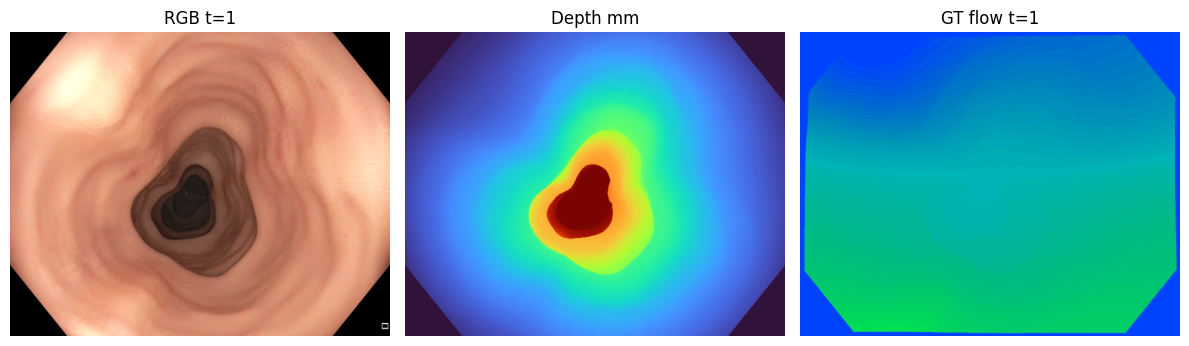

track:   0%|          | 0/49 [00:00<?, ?it/s]

ATE RMSE (mm, first-frame aligned): 9.618
map points: 148414


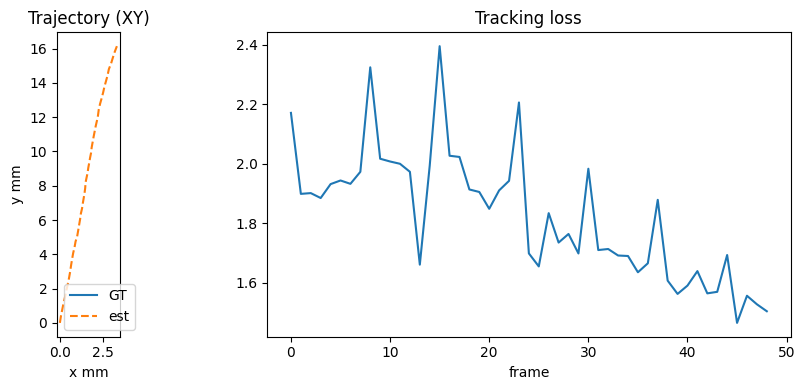

In [52]:
assert SEQ_DIR.exists(), f"place the unzipped sequence at {SEQ_DIR}"
data = load_c3vd_flat(SEQ_DIR, max_frames=MAX_FRAMES)
print({k: tuple(v.shape) if torch.is_tensor(v) else v for k, v in data.items()})

fig, ax = plt.subplots(1, 3, figsize=(12, 3.6))
ax[0].imshow(data["rgb"][1].permute(1, 2, 0).numpy())
ax[0].set_title("RGB t=1")
ax[0].axis("off")
ax[1].imshow(data["depth"][1].numpy(), cmap="turbo")
ax[1].set_title("Depth mm")
ax[1].axis("off")
ax[2].imshow(flow_to_hsv(data["flow"][1].permute(1, 2, 0).numpy()))
ax[2].set_title("GT flow t=1")
ax[2].axis("off")
plt.tight_layout()
plt.show()

est, cloud, logs = run_slam(data, use_gt_flow=True)
rmse, per = ate_rmse(est.cpu(), data["pose_c2w"])
print(f"ATE RMSE (mm, first-frame aligned): {rmse:.3f}")
print(f"map points: {0 if cloud.pts is None else cloud.pts.shape[0]}")

# trajectory XY (world mm)
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
gt_t = data["pose_c2w"][:, :3, 3].numpy()
es_t = est[:, :3, 3].cpu().numpy()
ax[0].plot(gt_t[:, 0], gt_t[:, 1], label="GT")
ax[0].plot(es_t[:, 0], es_t[:, 1], "--", label="est")
ax[0].set_aspect("equal")
ax[0].set_xlabel("x mm")
ax[0].set_ylabel("y mm")
ax[0].legend()
ax[0].set_title("Trajectory (XY)")
ax[1].plot(logs)
ax[1].set_title("Tracking loss")
ax[1].set_xlabel("frame")
plt.tight_layout()
plt.show()



## 11. Predicted vs GT flow (sanity check on GT poses)

If geometric flow from GT poses roughly matches C3VD `*_flow.tiff`, the warp / \(K\) / pose convention is consistent.



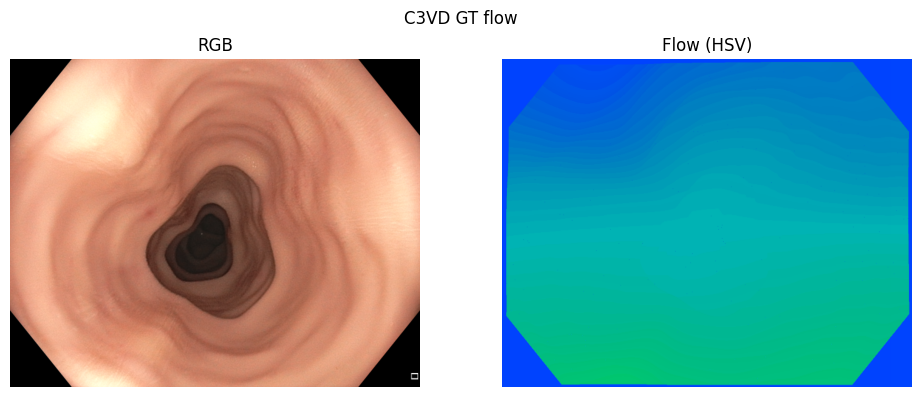

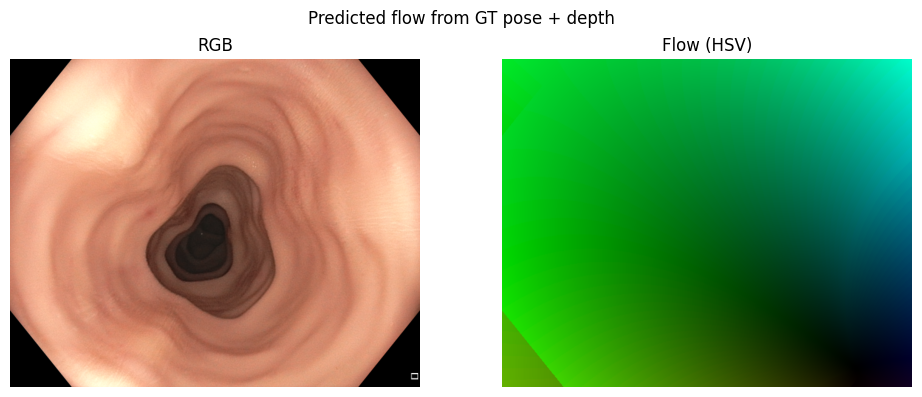

mean |flow_pred - flow_gt| px: 6.480990409851074


In [53]:
K = make_K()
t = min(5, data["rgb"].shape[0] - 1)
T_rel = relative_pose(data["pose_c2w"][t - 1].to(device), data["pose_c2w"][t].to(device))
pred = predicted_flow_and_warp(
    data["rgb"][t - 1].to(device), data["depth"][t - 1].to(device), T_rel, K
)
show_flow_row(data["rgb"][t], data["flow"][t], "C3VD GT flow")
show_flow_row(data["rgb"][t], pred["flow"].detach().cpu(), "Predicted flow from GT pose + depth")
print("mean |flow_pred - flow_gt| px:",
      float((pred["flow"].cpu() - data["flow"][t]).abs().mean()))



## 12. Hook: drop this into EndoGSLAM later

When `EndoGSLAM` is cloned, the mapping loop in `scripts/main.py` is the place to add:

```python
L_flow = flow_loss(predict_flow_from_gaussians(gaussians, pose_prev, pose_curr), flow_gt)
loss = lambda_im * L_rgb + lambda_depth * L_depth + lambda_grad * L_grad + lambda_flow * L_flow
```

Tracking in EndoGSLAM already freezes Gaussians (`lrs.means3D = 0`) and steps `cam_unnorm_rots` / `cam_trans`. Keep that split.

Files to borrow:

| Role | Path |
|------|------|
| Config | `configs/c3vd/c3vd_base.py`, `configs/data/c3vd.yaml` |
| Loop | `scripts/main.py` |
| Eval | `scripts/calc_metrics.py` |

`lambda_flow = 0.5` here is a starting point — ablate it.

